# Baseline

In [24]:
# Setting
# Baseline on DAWN Fog (no preprocessing)
from __future__ import annotations

import importlib.util
import json
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd

def ensure_pkg(import_name: str, pip_name: str | None = None) -> None:
    if importlib.util.find_spec(import_name) is not None:
        return
    pkg = pip_name or import_name
    print(f"Installing missing package: {pkg}")
    subprocess.run([sys.executable, "-m", "pip", "install", pkg], check=True)

# Ensure metrics deps are available
ensure_pkg("torchmetrics", "torchmetrics>=1.3.0")
ensure_pkg("pycocotools", "pycocotools>=2.0.7")

# Make sure repo root is on sys.path (matches project scripts)
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "src").exists() and str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RAW_ROOT = os.environ.get("DAWN_RAW_ROOT", str(REPO_ROOT / "dataset" / "DAWN"))
OUT_DIR = REPO_ROOT / "results" / "notebook_baseline_fog"

In [25]:
# Run evaluation (Fog only) using the existing script
cmd = [
    sys.executable,
    "src/detection/evaluate_yolo.py",
    "--data",
    "configs/dawn.yaml",
    "--model",
    "yolo26n.pt",
    "--split",
    "test",
    "--weather",
    "Fog",
    "--out_dir",
    str(OUT_DIR),
    "--raw_root",
    str(RAW_ROOT),
    "--viz_count",
    "30",
    "--allow_fallback",
    "--fallback_model",
    "yolov8n.pt",
]
print("Running:", " ".join(cmd))
p = subprocess.run(cmd, text=True, capture_output=True)
print(p.stdout)

if p.returncode != 0:
    print(p.stderr)
    raise RuntimeError(f"evaluate_yolo failed with exit code {p.returncode}")

# Load & display key metrics
metrics_path = OUT_DIR / "metrics.json"
per_weather_path = OUT_DIR / "per_weather_metrics.csv"
per_class_path = OUT_DIR / "per_class_metrics.csv"
metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
display(pd.DataFrame([metrics]))

# Per-weather + per-class metrics
per_weather = pd.read_csv(per_weather_path)
display(per_weather[per_weather["weather"] == "Fog"] if "weather" in per_weather.columns else per_weather)
per_class = pd.read_csv(per_class_path)
display(per_class)

Running: C:\Users\manh hung\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe src/detection/evaluate_yolo.py --data configs/dawn.yaml --model yolo26n.pt --split test --weather Fog --out_dir a:\HUST_on_GitHub\ProjectCV\results\notebook_baseline_fog --raw_root a:\HUST_on_GitHub\ProjectCV\dataset\DAWN --viz_count 30 --allow_fallback --fallback_model yolov8n.pt
Loaded model: yolo26n.pt
Processed 45/45

[Done] Wrote results to: A:\HUST_on_GitHub\ProjectCV\results\notebook_baseline_fog



,split,n_images,model,imgsz,conf,iou_nms,iou_match,map50,map5095,precision,recall,f1,mean_iou,latency,latency_by_weather
0,test,45,yolo26n.pt,640,0.25,0.7,0.5,0.078827,0.066326,0.928571,0.088435,0.161491,0.871974,"{'n': 45, 'mean_ms': 17.903617775947268, 'medi...","{'Fog': {'n': 45, 'mean_ms': 17.90361777594726..."


,weather,n_images,map50,map5095,precision,recall,f1,mean_iou
0,Fog,45,0.078827,0.066326,0.928571,0.088435,0.161491,0.871974


,class_id,class,ap50,ap5095,precision,recall,f1,mean_iou,tp,fp,fn
0,0,vehicle,0.098248,0.073246,0.961538,0.090909,0.166113,0.868370,25,1,250
1,1,person,0.059406,0.059406,0.500000,0.052632,0.095238,0.962071,1,1,18


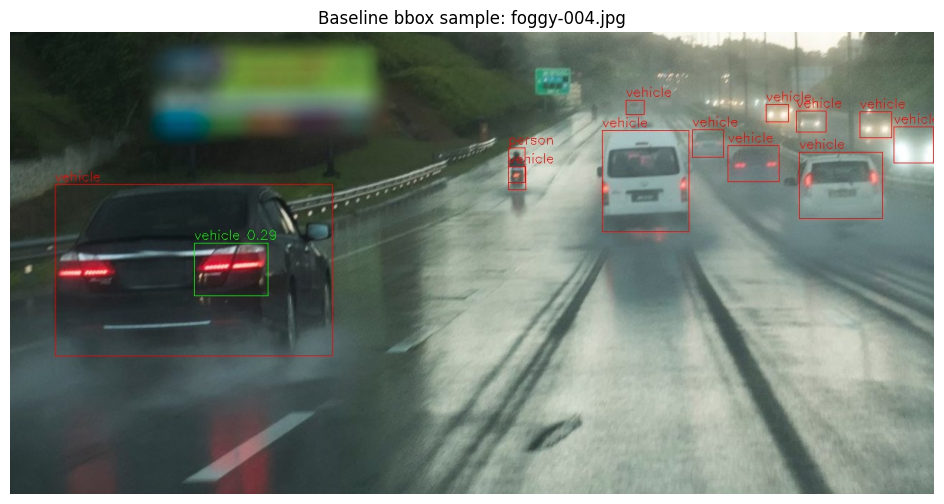

In [26]:
# Show one visualization image (bbox)
import cv2
import matplotlib.pyplot as plt
viz_dir = OUT_DIR / "predictions_visualized" / "Fog"
samples = sorted(viz_dir.rglob("*.jpg")) + sorted(viz_dir.rglob("*.png"))
if samples:
    img = cv2.imread(str(samples[0]), cv2.IMREAD_COLOR)
    if img is not None:
        plt.figure(figsize=(12, 6))
        plt.title(f"Baseline bbox sample: {samples[0].name}")
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
else:
    print("No visualization images found in:", viz_dir)

# Dark Channel Prior

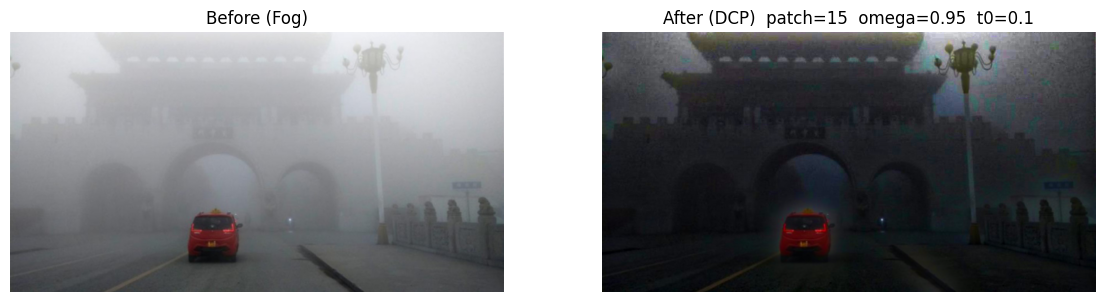

Saved:
 - a:\HUST_on_GitHub\ProjectCV\results\notebook_dcp_demo\foggy-001_dehazed.jpg
 - a:\HUST_on_GitHub\ProjectCV\results\notebook_dcp_demo\foggy-001_viz.jpg


In [27]:
# Dark Channel Prior: demo on a single Fog image
from __future__ import annotations

import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import yaml

# repo root on sys.path
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "src").exists() and str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.filters.dark_channel_prior import dehaze

# Load DCP params from configs/dcp.yaml (falls back to defaults if missing)
cfg_path = REPO_ROOT / "configs" / "dcp.yaml"
cfg = yaml.safe_load(cfg_path.read_text(encoding="utf-8")) if cfg_path.exists() else {}
dcp_cfg = (cfg.get("dcp") if isinstance(cfg, dict) else None) or {}
patch_size = int(dcp_cfg.get("patch_size", 15))
omega = float(dcp_cfg.get("omega", 0.95))
t0 = float(dcp_cfg.get("t0", 0.1))

in_path = REPO_ROOT / "dataset" / "DAWN" / "Fog" / "foggy-001.jpg"
out_dir = REPO_ROOT / "results" / "notebook_dcp_demo"
out_dir.mkdir(parents=True, exist_ok=True)

img_bgr = cv2.imread(str(in_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Failed to read: {in_path}")

out_bgr = dehaze(img_bgr, patch_size=patch_size, omega=omega, t0=t0)

out_path = out_dir / "foggy-001_dehazed.jpg"
viz_path = out_dir / "foggy-001_viz.jpg"
cv2.imwrite(str(out_path), out_bgr)
cv2.imwrite(str(viz_path), cv2.hconcat([img_bgr, out_bgr]))

# Display (convert BGR->RGB for matplotlib)
before_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
after_rgb = cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.title("Before (Fog)")
plt.imshow(before_rgb)
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title(f"After (DCP)  patch={patch_size}  omega={omega}  t0={t0}")
plt.imshow(after_rgb)
plt.axis("off")
plt.show()

print("Saved:")
print(" -", out_path)
print(" -", viz_path)

# Flow 1: DCP -> YOLOv26 -> result

DCP params from configs/dcp.yaml: patch=15 omega=0.95 t0=0.1
Running: C:\Users\manh hung\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe src/detection/evaluate_yolo.py --data configs/dawn.yaml --model yolo26n.pt --split test --weather Fog --processed_root a:\HUST_on_GitHub\ProjectCV\data\processed\dawn_yolo_dcp --out_dir a:\HUST_on_GitHub\ProjectCV\results\notebook_dcp_fog --raw_root a:\HUST_on_GitHub\ProjectCV\dataset\DAWN --viz_count 30 --allow_fallback --fallback_model yolov8n.pt
Loaded model: yolo26n.pt
Processed 45/45

[Done] Wrote results to: A:\HUST_on_GitHub\ProjectCV\results\notebook_dcp_fog



,split,n_images,model,imgsz,conf,iou_nms,iou_match,map50,map5095,precision,recall,f1,mean_iou,latency,latency_by_weather
0,test,45,yolo26n.pt,640,0.25,0.7,0.5,0.093834,0.074367,0.958333,0.078231,0.144654,0.862546,"{'n': 45, 'mean_ms': 22.742371112366932, 'medi...","{'Fog': {'n': 45, 'mean_ms': 22.74237111236693..."


,setting,map50,map5095,mean_iou,precision,recall,f1
0,baseline,0.078827,0.066326,0.871974,0.928571,0.088435,0.161491
1,dcp,0.093834,0.074367,0.862546,0.958333,0.078231,0.144654


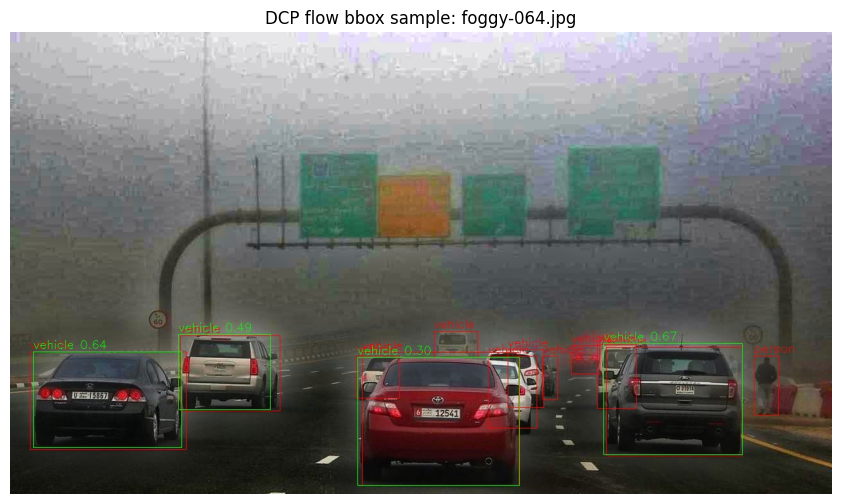

In [28]:
# Flow 1: DCP -> YOLOv26 -> results (DAWN Fog)
from __future__ import annotations

import json
import os
import shutil
import subprocess
import sys
from pathlib import Path

import pandas as pd
import yaml

REPO_ROOT = Path.cwd()
if (REPO_ROOT / "src").exists() and str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.filters.dark_channel_prior import dehaze
from src.utils.paths import dawn_processed_root

# Load DCP params from configs/dcp.yaml (fallback to defaults)
cfg_path = REPO_ROOT / "configs" / "dcp.yaml"
cfg = yaml.safe_load(cfg_path.read_text(encoding="utf-8")) if cfg_path.exists() else {}
dcp_cfg = (cfg.get("dcp") if isinstance(cfg, dict) else None) or {}
DCP_PATCH = int(dcp_cfg.get("patch_size", 15))
DCP_OMEGA = float(dcp_cfg.get("omega", 0.95))
DCP_T0 = float(dcp_cfg.get("t0", 0.1))

def _safe_link_or_copy(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return
    try:
        os.link(src, dst)
        return
    except Exception:
        pass
    try:
        os.symlink(src, dst)
        return
    except Exception:
        pass
    shutil.copy2(src, dst)

def build_dcp_processed_root(*, out_root: Path, split: str = "test", weather: str = "Fog", max_images: int = 0) -> Path:
    """Create a processed dataset root with DCP-dehazed images for one weather/split.
    Layout:
      out_root/images/<split>/<weather>/*.jpg
      out_root/labels/<split>/<weather>/*.txt  (hardlink/copy from baseline)
    """
    base = dawn_processed_root()
    in_img_dir = base / "images" / split / weather
    in_lbl_dir = base / "labels" / split / weather
    if not in_img_dir.exists():
        raise FileNotFoundError(f"Missing input images: {in_img_dir}")
    if not in_lbl_dir.exists():
        raise FileNotFoundError(f"Missing input labels: {in_lbl_dir}")
    out_img_dir = out_root / "images" / split / weather
    out_lbl_dir = out_root / "labels" / split / weather
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)
    imgs = sorted([p for p in in_img_dir.rglob("*") if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
    if max_images and max_images > 0:
        imgs = imgs[: int(max_images)]
    import cv2
    for p in imgs:
        rel = p.relative_to(in_img_dir)
        out_img_path = out_img_dir / rel
        img_bgr = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if img_bgr is None:
            continue
        out_bgr = dehaze(img_bgr, patch_size=DCP_PATCH, omega=DCP_OMEGA, t0=DCP_T0)
        out_img_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(out_img_path), out_bgr)
        # Copy/link label file if present
        lbl_in = (in_lbl_dir / rel).with_suffix(".txt")
        lbl_out = (out_lbl_dir / rel).with_suffix(".txt")
        if lbl_in.exists():
            _safe_link_or_copy(lbl_in, lbl_out)
    # Copy meta if exists (optional)
    meta_in = base / "_meta.json"
    if meta_in.exists():
        _safe_link_or_copy(meta_in, out_root / "_meta.json")
    return out_root

# 1) Create DCP-processed dataset root (Fog/test only)
DCP_ROOT = REPO_ROOT / "data" / "processed" / "dawn_yolo_dcp"
DCP_ROOT.mkdir(parents=True, exist_ok=True)
build_dcp_processed_root(out_root=DCP_ROOT, split="test", weather="Fog", max_images=0)

# 2) Run evaluation on Fog/test using the DCP processed_root
RAW_ROOT = os.environ.get("DAWN_RAW_ROOT", str(REPO_ROOT / "dataset" / "DAWN"))
OUT_DIR = REPO_ROOT / "results" / "notebook_dcp_fog"
cmd = [
    sys.executable,
    "src/detection/evaluate_yolo.py",
    "--data",
    "configs/dawn.yaml",
    "--model",
    "yolo26n.pt",
    "--split",
    "test",
    "--weather",
    "Fog",
    "--processed_root",
    str(DCP_ROOT),
    "--out_dir",
    str(OUT_DIR),
    "--raw_root",
    str(RAW_ROOT),
    "--viz_count",
    "30",
    "--allow_fallback",
    "--fallback_model",
    "yolov8n.pt",
]
print(f"DCP params from configs/dcp.yaml: patch={DCP_PATCH} omega={DCP_OMEGA} t0={DCP_T0}")
print("Running:", " ".join(cmd))
p = subprocess.run(cmd, text=True, capture_output=True)
print(p.stdout)
if p.returncode != 0:
    print(p.stderr)
    raise RuntimeError(f"evaluate_yolo failed with exit code {p.returncode}")

# 3) Load & show DCP metrics
dcp_metrics = json.loads((OUT_DIR / "metrics.json").read_text(encoding="utf-8"))
display(pd.DataFrame([dcp_metrics]))

# 4) Compare Baseline vs DCP on Fog
baseline_dir = REPO_ROOT / "results" / "notebook_baseline_fog"
baseline_metrics = json.loads((baseline_dir / "metrics.json").read_text(encoding="utf-8"))
cmp = pd.DataFrame([
    {
        "setting": "baseline",
        "map50": baseline_metrics.get("map50"),
        "map5095": baseline_metrics.get("map5095"),
        "mean_iou": baseline_metrics.get("mean_iou"),
        "precision": baseline_metrics.get("precision"),
        "recall": baseline_metrics.get("recall"),
        "f1": baseline_metrics.get("f1"),
    },
    {
        "setting": "dcp",
        "map50": dcp_metrics.get("map50"),
        "map5095": dcp_metrics.get("map5095"),
        "mean_iou": dcp_metrics.get("mean_iou"),
        "precision": dcp_metrics.get("precision"),
        "recall": dcp_metrics.get("recall"),
        "f1": dcp_metrics.get("f1"),
    },
])
display(cmp)

# 5) Show one visualization image (bbox) from DCP flow
import cv2
import matplotlib.pyplot as plt
viz_dir = OUT_DIR / "predictions_visualized" / "Fog"
samples = sorted(viz_dir.rglob("*.jpg")) + sorted(viz_dir.rglob("*.png"))
if samples:
    img = cv2.imread(str(samples[0]), cv2.IMREAD_COLOR)
    if img is not None:
        plt.figure(figsize=(12, 6))
        plt.title(f"DCP flow bbox sample: {samples[0].name}")
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
else:
    print("No visualization images found in:", viz_dir)